In [1]:
# 1. 数据准备：读取类别 + 动态生成 8000 张抽样清单
import json
import random
import yaml
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/wangsiyi1017/traffic/TrafficDetYolo")
DATA_YAML = str(DATA_ROOT / "data.yaml")

names = yaml.safe_load(open(DATA_YAML, encoding="utf-8"))["names"]
json.dump(names, open("/kaggle/working/traffic_classes.json", "w"), ensure_ascii=False, indent=2)
print("✅ 数据就绪:", DATA_ROOT)
print("类别列表:", names)

# 从 train 图片中随机抽取 8000 张
train_img_dir = DATA_ROOT / "train" / "images"
all_imgs = [f.name for f in train_img_dir.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
random.seed(42)
sample_imgs = random.sample(all_imgs, min(8000, len(all_imgs)))

sample_txt_path = "/kaggle/working/train_sample_v8n.txt"
with open(sample_txt_path, "w") as f:
    for img in sample_imgs:
        f.write(f"{DATA_ROOT}/train/images/{img}\n")

data = yaml.safe_load(open(DATA_YAML, encoding="utf-8"))
data["path"] = str(DATA_ROOT)
data["train"] = sample_txt_path
data["val"] = "val/images"

SAMPLE_YAML = "/kaggle/working/traffic_sample_v8n.yaml"
with open(SAMPLE_YAML, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(f"\n✅ 抽样配置生成完毕！图片数: {len(sample_imgs)} 张")
print(f"配置路径: {SAMPLE_YAML}")

✅ 数据就绪: /kaggle/input/datasets/wangsiyi1017/traffic/TrafficDetYolo
类别列表: ['Vehicle', 'Bus', 'Bicycle', 'Person', 'Engine', 'Truck', 'Tricycle', 'Obstacle', 'Pothole', 'Traffic Light', 'Traffic Sign']

✅ 抽样配置生成完毕！图片数: 8000 张
配置路径: /kaggle/working/traffic_sample_v8n.yaml


In [2]:
# 2. 安装 ultralytics + 预下载 yolov8n.pt
import importlib.util
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec("ultralytics") is None:
    print("正在安装 ultralytics...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)

from ultralytics import YOLO
model = YOLO("yolov8n.pt")  # 自动下载约 6MB
print("✅ 环境准备完毕，yolov8n.pt 已就绪")

正在安装 ultralytics...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ 环境准备完毕，yolov8n.pt 已就绪


In [3]:
# 3. 消融实验训练
from ultralytics import YOLO

EPOCHS, IMGSZ, BATCH, SEED = 5, 320, 4, 42
PROJECT_DIR = "/kaggle/working/traffic_models_v8n"

RUNS = [
    dict(name="v8n_baseline_lr0.01_wd0.0005", lr=0.01,  wd=0.0005),
    dict(name="v8n_lr0.005",                  lr=0.005, wd=0.0005),
    dict(name="v8n_lr0.001",                  lr=0.001, wd=0.0005),
]
BEST_LR = 0.01
for _wd in (0.001, 0.0001):
    RUNS.append(dict(name=f"v8n_wd{_wd}", lr=BEST_LR, wd=_wd))

for run in RUNS:
    print(f"\n{'='*60}")
    print(f"🚀 开始训练: {run['name']} (lr={run['lr']}, wd={run['wd']})")
    print(f"{'='*60}\n")

    model = YOLO("yolov8n.pt")
    model.train(
        data="/kaggle/working/traffic_sample_v8n.yaml",
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        seed=SEED,
        optimizer='SGD',
        lr0=run['lr'],
        lrf=1.0,
        weight_decay=run['wd'],
        project=PROJECT_DIR,
        name=run['name'],
        exist_ok=True,
        device=0,
        workers=2,
        cache=False,
        verbose=False
    )

print("\n✅ 全部 YOLOv8n 消融实验训练完成！")


🚀 开始训练: v8n_baseline_lr0.01_wd0.0005 (lr=0.01, wd=0.0005)

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_sample_v8n.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=1.0, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


        2/5     0.227G      1.328      1.999        1.3          9        320: 100% ━━━━━━━━━━━━ 2000/2000 17.7it/s 1:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 680/680 11.9it/s 57.3s
                   all       5439      13672      0.652      0.231      0.221      0.146

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/5     0.227G      1.427      2.002       1.37         11        320: 100% ━━━━━━━━━━━━ 2000/2000 17.5it/s 1:54
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 680/680 15.0it/s 45.4s
                   all       5439      13672      0.679        0.2      0.194       0.12

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        4/5     0.227G      1.488      2.009       1.41          5        320: 100% ━━━━━━━━━━━━ 2000/2000 17.0it/s 1:57
                 Class     Images  Inst

In [4]:
# 4. 汇总各次实验指标
import pandas as pd
import json
from pathlib import Path

RUN_DIR = Path("/kaggle/working/traffic_models_v8n")
RUNS = [
    dict(name="v8n_baseline_lr0.01_wd0.0005", lr=0.01,  wd=0.0005),
    dict(name="v8n_lr0.005",                  lr=0.005, wd=0.0005),
    dict(name="v8n_lr0.001",                  lr=0.001, wd=0.0005),
    dict(name="v8n_wd0.001",                  lr=0.01,  wd=0.001),
    dict(name="v8n_wd0.0001",                 lr=0.01,  wd=0.0001),
]

def pick_col(df, *needles):
    for c in df.columns:
        if all(k in c for k in needles):
            return c
    raise KeyError(f"未找到包含 {needles} 的列")

def parse_run(name, lr, wd):
    csv_path = RUN_DIR / name / "results.csv"
    if not csv_path.exists():
        print(f"⚠️ 跳过 {name}: 未找到结果文件")
        return None
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    if "epoch" not in df.columns:
        df.insert(0, "epoch", range(len(df)))
    try:
        c_ep = pick_col(df, "epoch")
        c_p = pick_col(df, "precision")
        c_r = pick_col(df, "recall")
        c_m50 = pick_col(df, "mAP50")
        c_m5095 = pick_col(df, "mAP50-95")
    except KeyError as e:
        print(f"⚠️ 解析 {name} 失败: {e}")
        return None

    best_i = df[c_m50].idxmax()
    best = df.loc[best_i]
    return dict(name=name, lr=lr, wd=wd, epochs=int(best[c_ep]) + 1,
                best_epoch=int(best[c_ep]) + 1,
                precision=float(best[c_p]), recall=float(best[c_r]),
                mAP50=float(best[c_m50]), mAP5095=float(best[c_m5095]),
                curves=dict(epoch=df[c_ep].astype(int).tolist(),
                            mAP50=df[c_m50].tolist(),
                            mAP5095=df[c_m5095].tolist()))

summaries = [s for s in (parse_run(**r) for r in RUNS) if s is not None]

if summaries:
    tbl = pd.DataFrame(summaries)[["name", "lr", "wd", "precision", "recall", "mAP50", "mAP5095"]]
    print("📊 YOLOv8n 消融实验结果汇总（按 mAP50 降序排列）")
    print("="*60)
    print(tbl.sort_values("mAP50", ascending=False).to_string(index=False))
    json.dump(summaries, open("/kaggle/working/yolov8n_runs_summary.json", "w"), ensure_ascii=False, indent=2)
    best = max(summaries, key=lambda s: s["mAP50"])
    print(f"\n🏆 表现最好的参数组合: {best['name']}")
    print(f"👉 最优 lr = {best['lr']}, 最优 wd = {best['wd']}, 最高 mAP50 = {best['mAP50']:.4f}")
else:
    print("❌ 没有找到任何有效实验结果")

📊 YOLOv8n 消融实验结果汇总（按 mAP50 降序排列）
                        name    lr     wd  precision  recall   mAP50  mAP5095
                 v8n_lr0.001 0.001 0.0005    0.66840 0.27836 0.28503  0.20037
                 v8n_lr0.005 0.005 0.0005    0.42912 0.25344 0.24597  0.15958
v8n_baseline_lr0.01_wd0.0005 0.010 0.0005    0.76950 0.21977 0.22786  0.15563
                v8n_wd0.0001 0.010 0.0001    0.52973 0.23128 0.22641  0.14802
                 v8n_wd0.001 0.010 0.0010    0.74363 0.21912 0.21824  0.14841

🏆 表现最好的参数组合: v8n_lr0.001
👉 最优 lr = 0.001, 最优 wd = 0.0005, 最高 mAP50 = 0.2850


In [5]:
# 5. 选出最优实验并导出权重
import shutil, pathlib

best = max(summaries, key=lambda s: s["mAP50"])
src = pathlib.Path("/kaggle/working/traffic_models_v8n") / best["name"] / "weights/best.pt"
shutil.copy2(src, "/kaggle/working/yolov8n_traffic_best.pt")
print(f"✅ 已导出测试权重: {best['name']} (mAP50={best['mAP50']:.4f})")

✅ 已导出测试权重: v8n_lr0.001 (mAP50=0.2850)


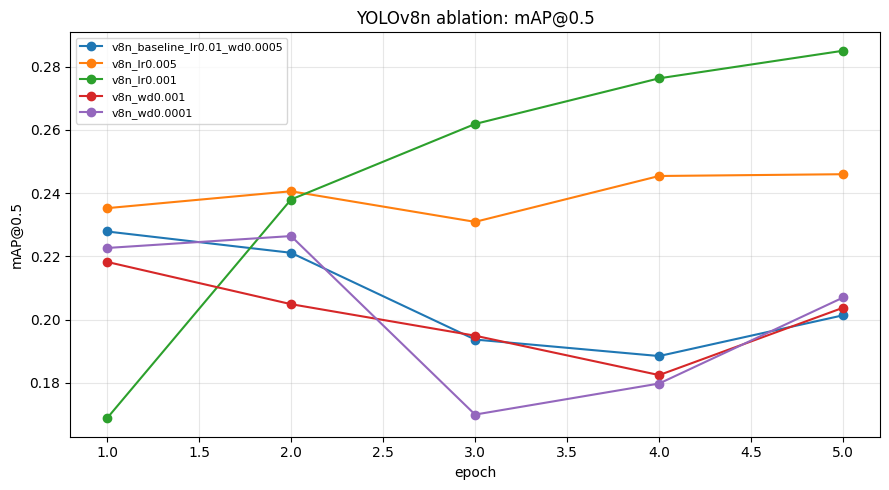

In [6]:
# 6. 绘制消融对比曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
for s in summaries:
    plt.plot(s["curves"]["epoch"], s["curves"]["mAP50"], marker="o", label=s["name"])
plt.xlabel("epoch"); plt.ylabel("mAP@0.5"); plt.grid(alpha=.3); plt.legend(fontsize=8)
plt.title("YOLOv8n ablation: mAP@0.5")
plt.tight_layout()
plt.savefig("/kaggle/working/yolov8n_ablation_curves.png", dpi=150)
plt.show()

In [7]:
# 7. 生成全量训练的绝对路径 yaml
import yaml
from pathlib import Path

DATA_ROOT = "/kaggle/input/datasets/wangsiyi1017/traffic/TrafficDetYolo"
with open(Path(DATA_ROOT) / "data.yaml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)
data["path"] = DATA_ROOT
data["train"] = "train/images"
data["val"] = "val/images"

NEW_YAML = "/kaggle/working/traffic_data_abs_v8n.yaml"
with open(NEW_YAML, "w", encoding="utf-8") as f:
    yaml.dump(data, f, sort_keys=False)
print(f"✅ 全量训练 yaml 已生成: {NEW_YAML}")

✅ 全量训练 yaml 已生成: /kaggle/working/traffic_data_abs_v8n.yaml


In [8]:
# 8. 全量数据最终训练（记得替换成第4步找出的最优参数）
from ultralytics import YOLO

BEST_LR = 0.001   
BEST_WD = 0.0005   

model = YOLO("yolov8n.pt")
model.train(
    data="/kaggle/working/traffic_data_abs_v8n.yaml",
    imgsz=640,
    epochs=20,
    patience=10,
    optimizer='SGD',
    lr0=BEST_LR,
    lrf=0.1,
    weight_decay=BEST_WD,
    batch=16,          # nano 模型很小，batch 可以设大一点
    seed=42,
    project="/kaggle/working/traffic_models_v8n_full",
    name="yolov8n_full_best",
    exist_ok=True,
    device=0,
    workers=2,
    cache=False
)

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_data_abs_v8n.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_full_best, nbs=64, nms=None, opset=None,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b15ca4daa50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [9]:
# 9. 打包全量训练结果
import shutil, os
from pathlib import Path

RESULT_DIR = Path("/kaggle/working/traffic_models_v8n_full/yolov8n_full_best")
ZIP_PATH = "/kaggle/working/yolov8n_full_best_results.zip"

if not RESULT_DIR.exists():
    print(f"❌ 找不到结果目录: {RESULT_DIR}")
else:
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)
    shutil.make_archive(base_name=ZIP_PATH.replace(".zip", ""), format='zip', root_dir=RESULT_DIR)
    zip_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
    print(f"✅ 打包完成: {ZIP_PATH} ({zip_size_mb:.1f} MB)")

✅ 打包完成: /kaggle/working/yolov8n_full_best_results.zip (20.2 MB)


📊 三模型 mAP@0.5 对比
   model  mAP50
 YOLOv8s 0.5338
 YOLOv8n 0.4897
YOLOv11s 0.5472


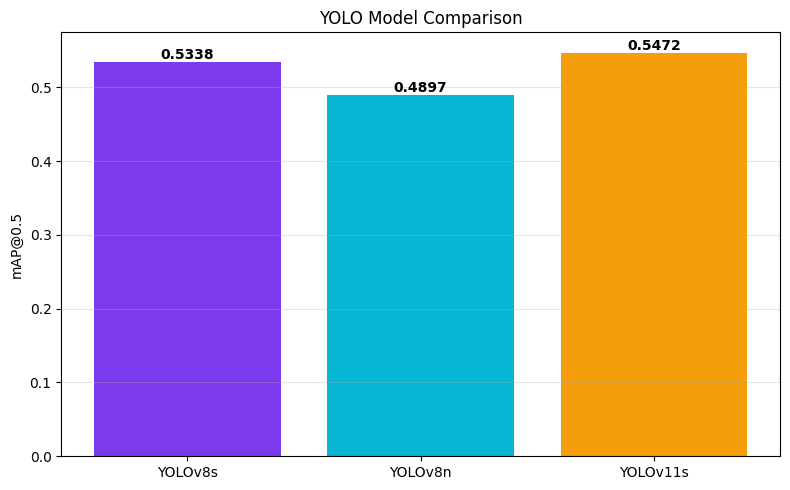

In [10]:
# 10. 三模型横向对比
import pandas as pd
import matplotlib.pyplot as plt

csv_files = {
    "YOLOv8s":  "/kaggle/input/datasets/wangsiyi1017/yolo-compare/yolo_compare/v8_results.csv",
    "YOLOv8n":  "/kaggle/working/traffic_models_v8n_full/yolov8n_full_best/results.csv",
    "YOLOv11s": "/kaggle/input/datasets/wangsiyi1017/yolo-compare/yolo_compare/v11_results.csv",
}

rows = []
for name, path in csv_files.items():
    if not Path(path).exists():
        print(f"⚠️ 跳过 {name}: 找不到 {path}")
        continue
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    mAP50_col = next(c for c in df.columns if "mAP50" in c and "95" not in c)
    best = df.loc[df[mAP50_col].idxmax()]
    rows.append(dict(model=name, mAP50=round(float(best[mAP50_col]), 4)))

if rows:
    df_cmp = pd.DataFrame(rows)
    print("📊 三模型 mAP@0.5 对比")
    print(df_cmp.to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.bar(df_cmp["model"], df_cmp["mAP50"], color=["#7c3aed", "#06b6d4", "#f59e0b"])
    for i, v in enumerate(df_cmp["mAP50"]):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")
    plt.ylabel("mAP@0.5"); plt.title("YOLO Model Comparison")
    plt.grid(alpha=.3, axis="y")
    plt.tight_layout()
    plt.savefig("/kaggle/working/three_model_comparison.png", dpi=150)
    plt.show()